In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import xgboost as xgb
import joblib
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, make_scorer
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, cross_val_score

In [2]:
df1 = pd.read_csv("../data/raw/Basic_table.csv")
df2 = pd.read_csv("../data/raw/Price_table.csv")
df3 = pd.read_csv("../data/raw/Trim_table.csv")

In [3]:
merged1 = df1.merge(df2, on=["Genmodel_ID","Genmodel"], how="inner")
print("Shape of merged1:", merged1.shape)

merged2 = merged1.merge(df3, on=["Maker","Genmodel_ID","Genmodel","Year"], how="inner")
print("Shape of merged2:", merged2.shape)

Shape of merged1: (6333, 7)
Shape of merged2: (191746, 12)


In [4]:
merged2.isna().sum()

Automaker       0
Automaker_ID    0
Genmodel        0
Genmodel_ID     0
Maker           0
Year            0
Entry_price     0
Trim            0
Price           0
Gas_emission    0
Fuel_type       0
Engine_size     0
dtype: int64

In [5]:
merged2.nunique()

Automaker          54
Automaker_ID       54
Genmodel          416
Genmodel_ID       426
Maker              54
Year               24
Entry_price      2105
Trim            38081
Price           18946
Gas_emission      328
Fuel_type           4
Engine_size       370
dtype: int64

Both the columns Automaker and Maker have 54 unique elements.

In [6]:
(merged2["Automaker"] == merged2["Maker"]).all()

np.True_

Since the columns Automaker and Maker are identical element-wise, the Automaker column is dropped.

In [7]:
merged2 = merged2.drop(columns = "Automaker")
merged2.shape

(191746, 11)

In [8]:
merged2.columns

Index(['Automaker_ID', 'Genmodel', 'Genmodel_ID', 'Maker', 'Year',
       'Entry_price', 'Trim', 'Price', 'Gas_emission', 'Fuel_type',
       'Engine_size'],
      dtype='object')

In [9]:
merged2.to_csv("../data/processed/Basic_Trim_Price_Details.csv",index=False)
car1 = pd.read_csv("../data/processed/Basic_Trim_Price_Details.csv")
car1.drop_duplicates(inplace = True)
car1 = car1.rename(columns = {"Price":"Price ($)"})
car1 = car1.rename(columns = {"Entry_price":"Entry Price ($)"})
car1 = car1.rename(columns = {"Engine_size":"Engine Size (L)"})
car1.head()

,Automaker_ID,Genmodel,Genmodel_ID,Maker,Year,Entry Price ($),Trim,Price ($),Gas_emission,Fuel_type,Engine Size (L)
0,2,124 Spider,2_1,Abarth,2019,29515,1.4 Turbo MultiAir 170hp Sequenziale Sportivo ...,31515,153,Petrol,1368
1,2,500,2_2,Abarth,2009,13400,500 1.4 16V T-Jet (09) 3d,13400,139,Petrol,1368
2,2,500,2_2,Abarth,2010,13945,500 1.4 16V T-Jet (09) 3d,13945,139,Petrol,1368
3,2,500,2_2,Abarth,2011,13945,500 1.4 16V T-Jet (09) 3d,13945,139,Petrol,1368
4,2,500,2_2,Abarth,2011,13945,500 1.4 16V T-Jet (09) 3d,14242,139,Petrol,1368


In [10]:
df4 = pd.read_csv("../data/raw/Ad_table (extra).csv")
df4.shape


(268255, 24)

In [11]:
df4.isna().mean()*100

Maker            0.000000
 Genmodel        0.000000
 Genmodel_ID     0.000000
Adv_ID           0.000000
Adv_year         0.000000
Adv_month        0.000000
Color            8.154554
Reg_year         0.002609
Bodytype         0.355632
Runned_Miles     0.393283
Engin_size       0.769417
Gearbox          0.062254
Fuel_type        0.152467
Price            0.426833
Engine_power    11.858493
Annual_Tax      17.399489
Wheelbase       10.437084
Height          10.363647
Width           10.467652
Length          10.363647
Average_mpg     15.631768
Top_speed       16.253937
Seat_num         2.413375
Door_num         1.697266
dtype: float64

Since the percentage of NaN entries in a particular column is less than 20%, the rows having NaN entries rather than dropping the entire column.

In [12]:
car2 = df4.dropna(how = "any")
car2 = car2.copy()    # Making a full copy to prevent chained assignment issues
car2.shape

(188182, 24)

In [13]:
car2.columns

Index(['Maker', ' Genmodel', ' Genmodel_ID', 'Adv_ID', 'Adv_year', 'Adv_month',
       'Color', 'Reg_year', 'Bodytype', 'Runned_Miles', 'Engin_size',
       'Gearbox', 'Fuel_type', 'Price', 'Engine_power', 'Annual_Tax',
       'Wheelbase', 'Height', 'Width', 'Length', 'Average_mpg', 'Top_speed',
       'Seat_num', 'Door_num'],
      dtype='object')

In [14]:
car2.rename(columns={'Engin_size':'Engine_size', ' Genmodel':'Genmodel', ' Genmodel_ID':'Genmodel_ID'}, inplace = True)
car2.columns

Index(['Maker', 'Genmodel', 'Genmodel_ID', 'Adv_ID', 'Adv_year', 'Adv_month',
       'Color', 'Reg_year', 'Bodytype', 'Runned_Miles', 'Engine_size',
       'Gearbox', 'Fuel_type', 'Price', 'Engine_power', 'Annual_Tax',
       'Wheelbase', 'Height', 'Width', 'Length', 'Average_mpg', 'Top_speed',
       'Seat_num', 'Door_num'],
      dtype='object')

In [15]:
car2.drop_duplicates(inplace=True)
car2.to_csv("../data/processed/Adv_Details.csv", index = False)
car2.head()

,Maker,Genmodel,Genmodel_ID,Adv_ID,Adv_year,Adv_month,Color,Reg_year,Bodytype,Runned_Miles,...,Engine_power,Annual_Tax,Wheelbase,Height,Width,Length,Average_mpg,Top_speed,Seat_num,Door_num
1,Bentley,Arnage,10_1,10_1$$2,2018,6,Grey,2002.0,Saloon,44000,...,450.0,315,3116.0,1515.0,2125.0,5390.0,13.7 mpg,179 mph,5.0,4.0
2,Bentley,Arnage,10_1,10_1$$3,2017,11,Blue,2002.0,Saloon,55000,...,400.0,315,3116.0,1515.0,2125.0,5390.0,14.7 mpg,155 mph,5.0,4.0
5,Bentley,Arnage,10_1,10_1$$6,2017,12,Blue,2002.0,Saloon,55000,...,450.0,315,3116.0,1515.0,2125.0,5390.0,13.7 mpg,179 mph,5.0,4.0
11,Bentley,Arnage,10_1,10_1$$12,2018,6,Silver,2002.0,Saloon,52000,...,450.0,315,3116.0,1515.0,2125.0,5390.0,13.7 mpg,179 mph,5.0,4.0
13,Bentley,Arnage,10_1,10_1$$14,2018,7,Blue,2002.0,Saloon,58000,...,450.0,315,3116.0,1515.0,2125.0,5390.0,13.7 mpg,179 mph,5.0,4.0


In [16]:
car2.dtypes

Maker            object
Genmodel         object
Genmodel_ID      object
Adv_ID           object
Adv_year          int64
Adv_month         int64
Color            object
Reg_year        float64
Bodytype         object
Runned_Miles     object
Engine_size      object
Gearbox          object
Fuel_type        object
Price           float64
Engine_power    float64
Annual_Tax       object
Wheelbase       float64
Height          float64
Width           float64
Length          float64
Average_mpg      object
Top_speed        object
Seat_num        float64
Door_num        float64
dtype: object

In [17]:
# Converting columns to their appropriate data types
car2["Reg_year"] = car2["Reg_year"].astype("int64")
car2["Average_mpg"] = car2["Average_mpg"].str.replace('mpg','', regex= False).astype("float64")
car2["Top_speed"] = car2["Top_speed"].str.replace('mph','', regex= False).astype("float64")

# Renaming columns for better readability
car2 = car2.rename(columns = {"Top_speed":"Top_speed (mph)"})
car2 = car2.rename(columns = {"Average_mpg":"Average MPG"})
car2 = car2.rename(columns = {"Engine_size":"Engine Size (L)"})
car2 = car2.rename(columns = {"Engine_power":"Engine Power"})
car2.dtypes

Maker               object
Genmodel            object
Genmodel_ID         object
Adv_ID              object
Adv_year             int64
Adv_month            int64
Color               object
Reg_year             int64
Bodytype            object
Runned_Miles        object
Engine Size (L)     object
Gearbox             object
Fuel_type           object
Price              float64
Engine Power       float64
Annual_Tax          object
Wheelbase          float64
Height             float64
Width              float64
Length             float64
Average MPG        float64
Top_speed (mph)    float64
Seat_num           float64
Door_num           float64
dtype: object

In [18]:
car2.head()

,Maker,Genmodel,Genmodel_ID,Adv_ID,Adv_year,Adv_month,Color,Reg_year,Bodytype,Runned_Miles,...,Engine Power,Annual_Tax,Wheelbase,Height,Width,Length,Average MPG,Top_speed (mph),Seat_num,Door_num
1,Bentley,Arnage,10_1,10_1$$2,2018,6,Grey,2002,Saloon,44000,...,450.0,315,3116.0,1515.0,2125.0,5390.0,13.7,179.0,5.0,4.0
2,Bentley,Arnage,10_1,10_1$$3,2017,11,Blue,2002,Saloon,55000,...,400.0,315,3116.0,1515.0,2125.0,5390.0,14.7,155.0,5.0,4.0
5,Bentley,Arnage,10_1,10_1$$6,2017,12,Blue,2002,Saloon,55000,...,450.0,315,3116.0,1515.0,2125.0,5390.0,13.7,179.0,5.0,4.0
11,Bentley,Arnage,10_1,10_1$$12,2018,6,Silver,2002,Saloon,52000,...,450.0,315,3116.0,1515.0,2125.0,5390.0,13.7,179.0,5.0,4.0
13,Bentley,Arnage,10_1,10_1$$14,2018,7,Blue,2002,Saloon,58000,...,450.0,315,3116.0,1515.0,2125.0,5390.0,13.7,179.0,5.0,4.0


In [19]:
df5 = pd.read_csv("../data/raw/Image_table.csv")
df5.columns
df5.isna().mean()*100

Genmodel_ID             0.000000
Image_ID                0.000000
Image_name              0.000000
Predicted_viewpoint     0.000000
Quality_check          94.007855
dtype: float64

Quality_check column has 94% NaN entries, hence dropped.

In [20]:
df5 = df5.drop(columns = 'Quality_check')
df5.columns

Index(['Genmodel_ID', 'Image_ID', 'Image_name', 'Predicted_viewpoint'], dtype='object')

In [21]:
df6 = pd.read_csv("../data/raw/Sales_table.csv")
df6.shape
df6.columns

Index(['Maker', 'Genmodel', 'Genmodel_ID', '2020', '2019', '2018', '2017',
       '2016', '2015', '2014', '2013', '2012', '2011', '2010', '2009', '2008',
       '2007', '2006', '2005', '2004', '2003', '2002', '2001'],
      dtype='object')

In [22]:
car3 = df5.merge(df6, on = ['Genmodel_ID'], how = "inner")
car3.shape

(1444026, 26)

In [23]:
car3.isna().sum()
car3.drop_duplicates(inplace=True)
car3.to_csv('../data/processed/Image_Sales_Details.csv', index = False)
car3.head()

,Genmodel_ID,Image_ID,Image_name,Predicted_viewpoint,Maker,Genmodel,2020,2019,2018,2017,...,2010,2009,2008,2007,2006,2005,2004,2003,2002,2001
0,2_1,2_1$$1$$1,Abarth$$124 Spider$$2017$$Blue$$2_1$$1$$image_...,45,ABARTH,ABARTH 124,0,19,27,60,...,0,0,0,0,0,0,0,0,0,0
1,2_1,2_1$$1$$1,Abarth$$124 Spider$$2017$$Blue$$2_1$$1$$image_...,45,ABARTH,ABARTH SPIDER,0,223,777,409,...,0,0,0,0,0,0,0,0,0,0
2,2_1,2_1$$10$$11,Abarth$$124 Spider$$2017$$Blue$$2_1$$10$$image...,45,ABARTH,ABARTH 124,0,19,27,60,...,0,0,0,0,0,0,0,0,0,0
3,2_1,2_1$$10$$11,Abarth$$124 Spider$$2017$$Blue$$2_1$$10$$image...,45,ABARTH,ABARTH SPIDER,0,223,777,409,...,0,0,0,0,0,0,0,0,0,0
4,2_1,2_1$$10$$16,Abarth$$124 Spider$$2017$$Blue$$2_1$$10$$image...,0,ABARTH,ABARTH 124,0,19,27,60,...,0,0,0,0,0,0,0,0,0,0


The 6 initial data files have been arranged into 3 csv files after proper cleaning and handling missing values.

**Exploratory Data Analysis**

*Which car models are most popular? Which car has the highest no.of sales?*

In [24]:
car3["Total Sales"] = car3.iloc[:,6:].sum(axis=1) 
Total_sales_per_maker = car3.groupby("Maker")["Total Sales"].sum().sort_values(ascending=False)
Top_maker = Total_sales_per_maker.index[0]
Top_maker_models = (car3[car3["Maker"] == Top_maker].groupby("Genmodel")["Total Sales"].sum().sort_values(ascending=False))

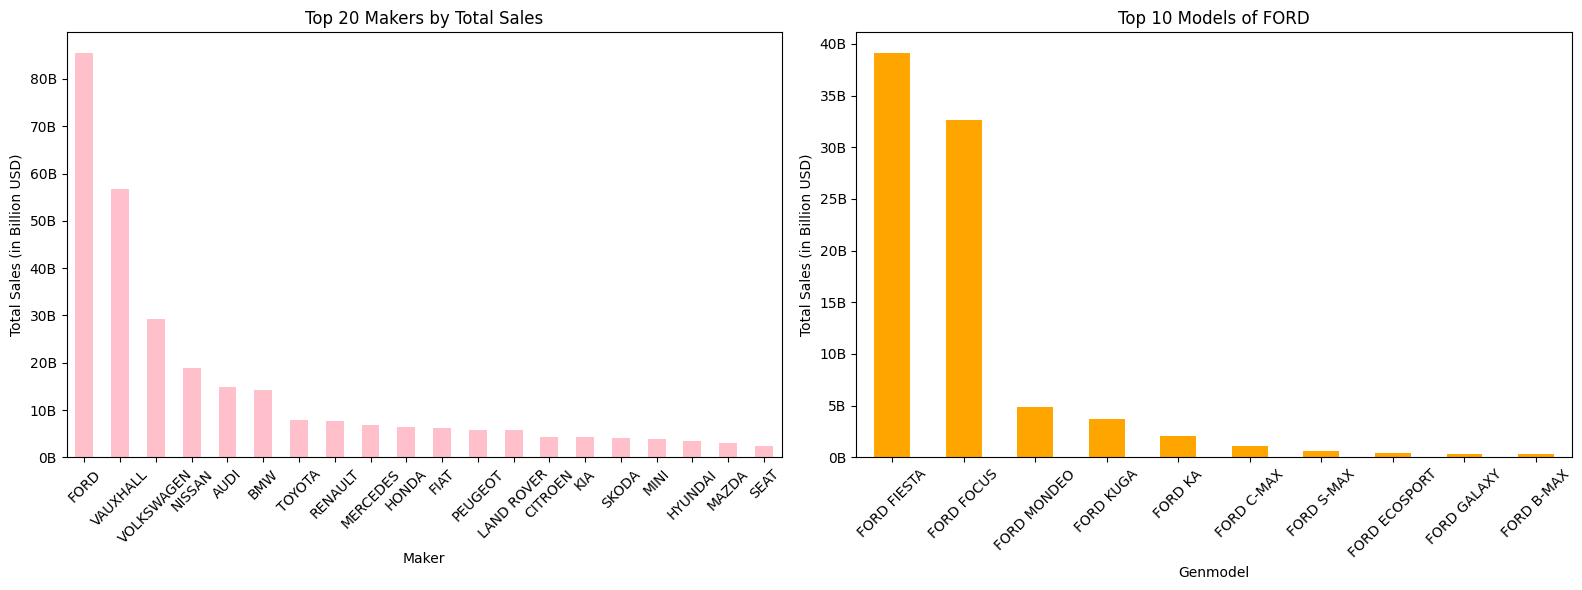

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16,6))

# Left: Top 20 Makers by Total Sales
Total_sales_per_maker.head(20).plot(kind="bar", ax=axes[0], color="pink")
axes[0].set_title("Top 20 Makers by Total Sales")
axes[0].set_ylabel("Total Sales (in Billion USD)")
axes[0].tick_params(axis="x", rotation=45)
axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1e9:.0f}B'))

# Right: Top 10 Models of the Top_maker
Top_maker_models.head(10).plot(kind="bar", ax=axes[1], color="orange")
axes[1].set_title(f"Top 10 Models of {Top_maker}")
axes[1].set_ylabel("Total Sales (in Billion USD)")
axes[1].tick_params(axis="x", rotation=45)
axes[1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1e9:.0f}B'))

plt.tight_layout()

# Saving the figures
plt.savefig("../screenshots/combined_bar_plot.png", dpi=300, bbox_inches='tight')

plt.show()


*Ford* is the most dominant car maker company with more than 80 Billion sales over a span of two decades.
    *Fiesta* is the most in demand, top performing model of Ford with around 40 Billion sales followed by *Focus*.

*Fuel efficiency (mpg) vs Top speed(mph)*

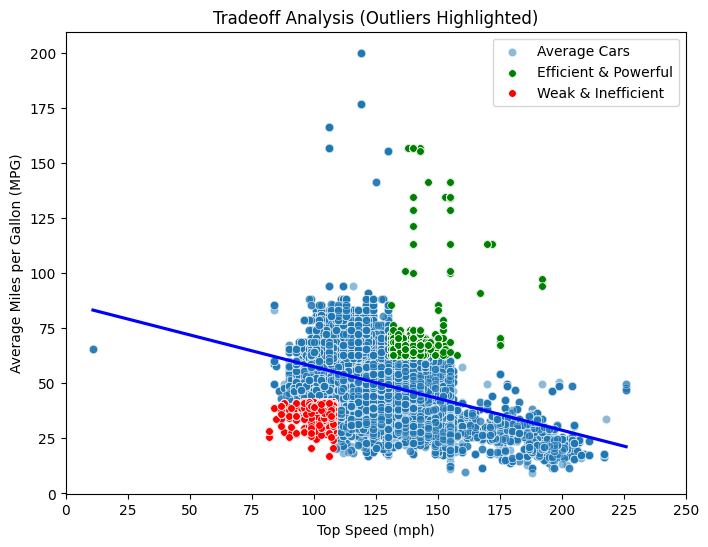

In [26]:
# Finding outliers
mph_high = car2["Top_speed (mph)"].quantile(0.75)
mpg_high = car2["Average MPG"].quantile(0.75)

best_outliers = car2[(car2["Top_speed (mph)"] > mph_high) & (car2["Average MPG"] > mpg_high)]

mph_low = car2["Top_speed (mph)"].quantile(0.25)
mpg_low = car2["Average MPG"].quantile(0.25)

worst_outliers = car2[(car2["Top_speed (mph)"] < mph_low) & (car2["Average MPG"] < mpg_low)]

plt.figure(figsize=(8,6))

# Average cars
sns.scatterplot(data=car2, x="Top_speed (mph)", y="Average MPG", alpha=0.5, label="Average Cars")

# Best outliers 
sns.scatterplot(data=best_outliers, x="Top_speed (mph)", y="Average MPG", color="green", s=30, label="Efficient & Powerful")

# Worst outliers
sns.scatterplot(data=worst_outliers, x="Top_speed (mph)", y="Average MPG", color="red", s=30, label="Weak & Inefficient")

# Regression line
sns.regplot(data=car2, x="Top_speed (mph)", y="Average MPG", scatter=False, color="blue")


plt.title("Tradeoff Analysis (Outliers Highlighted)")
plt.xlabel("Top Speed (mph)")
plt.ylabel("Average Miles per Gallon (MPG)")
plt.xticks(np.arange(0,275,25))
plt.legend()

# Saving the figure
plt.savefig("../screenshots/scatter_reg_plot.png", dpi=300, bbox_inches='tight')

plt.show()



There exists a negative tradeoff between top speed and fuel efficiency, i.e., faster cars tend to have lower average MPG. However, certain models (green clusters) outperform the tradeoff, achieving both high speed and efficiency. Conversely, some cars (red clusters) perform poorly on both dimensions, making them clear underperformers.

*Which car makers earn the most from trims? Is it driven by high premiums or high sales volume?*

In [27]:
car1["price_diff"] = car1["Price ($)"] - car1["Entry Price ($)"]
car1.head()

,Automaker_ID,Genmodel,Genmodel_ID,Maker,Year,Entry Price ($),Trim,Price ($),Gas_emission,Fuel_type,Engine Size (L),price_diff
0,2,124 Spider,2_1,Abarth,2019,29515,1.4 Turbo MultiAir 170hp Sequenziale Sportivo ...,31515,153,Petrol,1368,2000
1,2,500,2_2,Abarth,2009,13400,500 1.4 16V T-Jet (09) 3d,13400,139,Petrol,1368,0
2,2,500,2_2,Abarth,2010,13945,500 1.4 16V T-Jet (09) 3d,13945,139,Petrol,1368,0
3,2,500,2_2,Abarth,2011,13945,500 1.4 16V T-Jet (09) 3d,13945,139,Petrol,1368,0
4,2,500,2_2,Abarth,2011,13945,500 1.4 16V T-Jet (09) 3d,14242,139,Petrol,1368,297


In [28]:
top5_data = car1.groupby("Maker")["price_diff"].mean().sort_values(ascending=False).head(5)
Best_maker = car1.groupby("Maker")["price_diff"].sum().sort_values(ascending=False).index[0]
Best_maker_data = car1[car1["Maker"]== Best_maker]

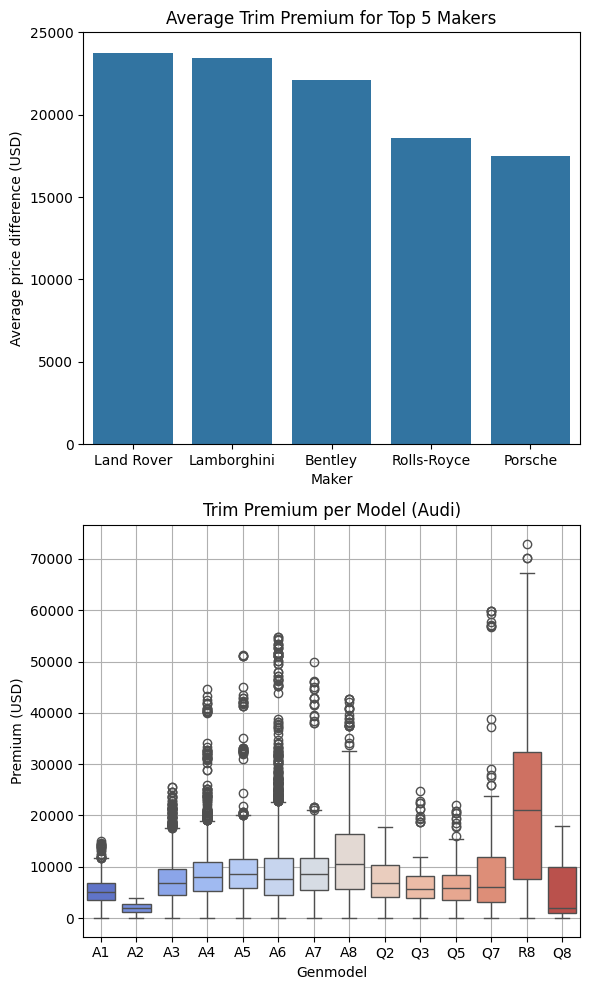

In [29]:
fig, axes = plt.subplots(2, 1, figsize=(6,10))

# Plot 1: Top 5 makers (average premium)
sns.barplot(x = top5_data.index, y = top5_data.values, estimator = np.mean, ax= axes[0])
axes[0].set_title("Average Trim Premium for Top 5 Makers")
axes[0].set_ylabel("Average price difference (USD)")
axes[0].set_yticks(np.arange(0,30000,5000))

# Plot 2: Best maker models
sns.boxplot(data=Best_maker_data, x="Genmodel", y="price_diff", palette="coolwarm", hue="Genmodel", legend = False, ax=axes[1])
axes[1].set_title(f"Trim Premium per Model ({Best_maker})")
axes[1].set_ylabel("Premium (USD)")
axes[1].tick_params(axis='x')
plt.grid(True)

plt.tight_layout()

# Saving the figures
plt.savefig("../screenshots/bar_box_plot.png", dpi=300, bbox_inches='tight')

plt.show()


+ From the bar plot, it is evident that Land Rover and Lamborghini have nearly identical average trim premiums on their base models, making them the makers with the highest premiums per car.

+ The box plot, however, shows that Audi dominates in terms of sales volume. R8 has the highest median trim premium of about $20000. The model A6 has the maximum number of outliers even though the median  trim premium is much less compared to that of R8.

This contrast highlights two distinct strategies in the car market: luxury makers rely on high margins per car, while mass-market makers like Audi leverage high volume to maximize total revenue.

**Machine Learning and Model Deployment**

In [30]:
car3["Average Sales"] = car3.iloc[:,6:-1].mean(axis=1)
car3["Recent Sales"] = car3.iloc[:, 6:11].mean(axis=1)   #Taking the mean of the last 5years of sales as the recent sales.
car2["Car Age"] = 2025 - car2["Reg_year"]
car3.head()

,Genmodel_ID,Image_ID,Image_name,Predicted_viewpoint,Maker,Genmodel,2020,2019,2018,2017,...,2007,2006,2005,2004,2003,2002,2001,Total Sales,Average Sales,Recent Sales
0,2_1,2_1$$1$$1,Abarth$$124 Spider$$2017$$Blue$$2_1$$1$$image_...,45,ABARTH,ABARTH 124,0,19,27,60,...,0,0,0,0,0,0,0,106,5.30,21.2
1,2_1,2_1$$1$$1,Abarth$$124 Spider$$2017$$Blue$$2_1$$1$$image_...,45,ABARTH,ABARTH SPIDER,0,223,777,409,...,0,0,0,0,0,0,0,1585,79.25,317.0
2,2_1,2_1$$10$$11,Abarth$$124 Spider$$2017$$Blue$$2_1$$10$$image...,45,ABARTH,ABARTH 124,0,19,27,60,...,0,0,0,0,0,0,0,106,5.30,21.2
3,2_1,2_1$$10$$11,Abarth$$124 Spider$$2017$$Blue$$2_1$$10$$image...,45,ABARTH,ABARTH SPIDER,0,223,777,409,...,0,0,0,0,0,0,0,1585,79.25,317.0
4,2_1,2_1$$10$$16,Abarth$$124 Spider$$2017$$Blue$$2_1$$10$$image...,0,ABARTH,ABARTH 124,0,19,27,60,...,0,0,0,0,0,0,0,106,5.30,21.2


In [31]:
basic_features = car1[["Genmodel_ID", "Entry Price ($)", "Trim","Price ($)" ,"Fuel_type","Engine Size (L)"]]
ad_features = car2[["Genmodel_ID","Car Age","Color","Bodytype","Runned_Miles","Gearbox","Engine Power","Average MPG","Top_speed (mph)","Seat_num","Door_num"]]
sales_features = car3[["Genmodel_ID", "Average Sales", "Recent Sales"]]

In [32]:
ad_features_unique = ad_features.drop_duplicates(subset=["Genmodel_ID"])
df = basic_features.merge(ad_features_unique, on="Genmodel_ID", how="left")

In [33]:
sales_features_unique = sales_features.drop_duplicates(subset=["Genmodel_ID"])
df = df.merge(sales_features_unique, on="Genmodel_ID", how="left")

In [34]:
df.head()

,Genmodel_ID,Entry Price ($),Trim,Price ($),Fuel_type,Engine Size (L),Car Age,Color,Bodytype,Runned_Miles,Gearbox,Engine Power,Average MPG,Top_speed (mph),Seat_num,Door_num,Average Sales,Recent Sales
0,2_1,29515,1.4 Turbo MultiAir 170hp Sequenziale Sportivo ...,31515,Petrol,1368,8.0,Red,Convertible,5874,Automatic,170.0,42.8,142.0,2.0,2.0,5.3,21.2
1,2_2,13400,500 1.4 16V T-Jet (09) 3d,13400,Petrol,1368,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2_2,13945,500 1.4 16V T-Jet (09) 3d,13945,Petrol,1368,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2_2,13945,500 1.4 16V T-Jet (09) 3d,13945,Petrol,1368,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2_2,13945,500 1.4 16V T-Jet (09) 3d,14242,Petrol,1368,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [35]:
df.isna().mean()*100

Genmodel_ID        0.000000
Entry Price ($)    0.000000
Trim               0.000000
Price ($)          0.000000
Fuel_type          0.000000
Engine Size (L)    0.000000
Car Age            2.746863
Color              2.746863
Bodytype           2.746863
Runned_Miles       2.746863
Gearbox            2.746863
Engine Power       2.746863
Average MPG        2.746863
Top_speed (mph)    2.746863
Seat_num           2.746863
Door_num           2.746863
Average Sales      1.578651
Recent Sales       1.578651
dtype: float64

Since the percentage of NaN entries in a particular column is less than 5%, the rows having NaN entries are removed instead of dropping the entire column.

In [36]:
df = df.dropna(how="any")
df.head()

,Genmodel_ID,Entry Price ($),Trim,Price ($),Fuel_type,Engine Size (L),Car Age,Color,Bodytype,Runned_Miles,Gearbox,Engine Power,Average MPG,Top_speed (mph),Seat_num,Door_num,Average Sales,Recent Sales
0,2_1,29515,1.4 Turbo MultiAir 170hp Sequenziale Sportivo ...,31515,Petrol,1368,8.0,Red,Convertible,5874,Automatic,170.0,42.8,142.0,2.0,2.0,5.3,21.2
20,2_4,17500,595 Convertible1.4 T-Jet Competizione 2d,20400,Petrol,1368,9.0,Blue,Hatchback,17832,Manual,160.0,47.1,130.0,4.0,3.0,906.4,3068.8
21,2_4,17500,595 Convertible1.4 T-Jet Competizione 2d Auto,21700,Petrol,1368,9.0,Blue,Hatchback,17832,Manual,160.0,47.1,130.0,4.0,3.0,906.4,3068.8
22,2_4,17500,595 Convertible1.4 T-Jet Turismo 2d,19400,Petrol,1368,9.0,Blue,Hatchback,17832,Manual,160.0,47.1,130.0,4.0,3.0,906.4,3068.8
23,2_4,17500,595 Convertible1.4 T-Jet Turismo 2d Auto,20700,Petrol,1368,9.0,Blue,Hatchback,17832,Manual,160.0,47.1,130.0,4.0,3.0,906.4,3068.8


In [37]:
# Define feature sets
numeric_features = ['Engine Power', 'Runned_Miles', 'Average MPG', 'Top_speed (mph)',
                    'Average Sales', 'Recent Sales','Entry Price ($)' ,'Engine Size (L)',
                    'Seat_num','Door_num','Car Age']
categorical_features = ['Trim', 'Gearbox', 'Color','Bodytype','Fuel_type']
X = df[numeric_features + categorical_features]
y = df['Price ($)']

# Create ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),           # scale numeric features
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), categorical_features)  # encode categorical features
    ]
)

Cross-Validation Performance Comparison:

              Model  R² Mean ± Std   MAE Mean ± Std
0  Ridge Regression  0.989 ± 0.001    939.10 ± 8.44
1           XGBoost  0.967 ± 0.001  1977.10 ± 17.64


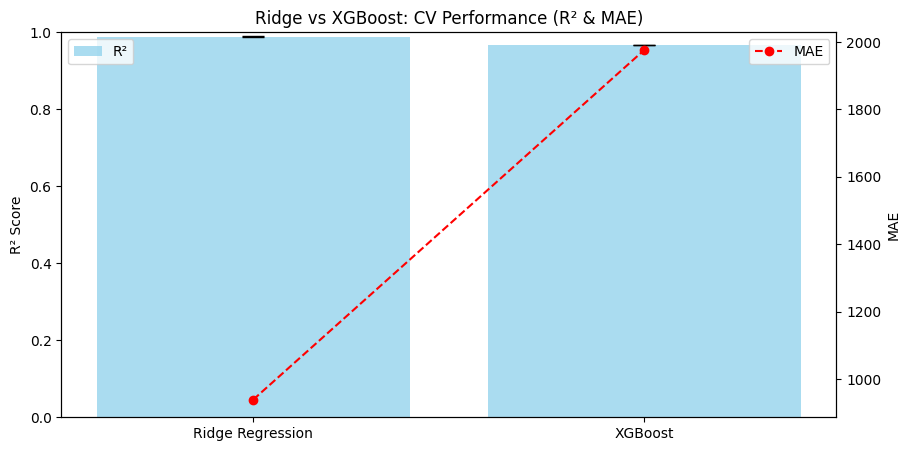

In [38]:
# Defining Pipelines
ridge_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', Ridge(alpha=1.0))
])

xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', xgb.XGBRegressor(n_estimators=100, max_depth=5, random_state=42))
])

# Setting up Cross-Validation (CV)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# MAE scorer 
mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)

# Running CV for Ridge
ridge_r2_scores = cross_val_score(ridge_pipeline, X, y, cv=kf, scoring='r2')
ridge_mae_scores = cross_val_score(ridge_pipeline, X, y, cv=kf, scoring=mae_scorer)
ridge_mae_scores = -ridge_mae_scores  # convert to positive MAE


# Running CV for XGBoost
xgb_r2_scores = cross_val_score(xgb_pipeline, X, y, cv=kf, scoring='r2')
xgb_mae_scores = cross_val_score(xgb_pipeline, X, y, cv=kf, scoring=mae_scorer)
xgb_mae_scores = -xgb_mae_scores  # positive MAE

# Comparison Table
comparison_df = pd.DataFrame({
    "Model": ["Ridge Regression", "XGBoost"],
    "R² Mean ± Std": [f"{np.mean(ridge_r2_scores):.3f} ± {np.std(ridge_r2_scores):.3f}",
                       f"{np.mean(xgb_r2_scores):.3f} ± {np.std(xgb_r2_scores):.3f}"],
    "MAE Mean ± Std": [f"{np.mean(ridge_mae_scores):.2f} ± {np.std(ridge_mae_scores):.2f}",
                       f"{np.mean(xgb_mae_scores):.2f} ± {np.std(xgb_mae_scores):.2f}"]
})

print("Cross-Validation Performance Comparison:\n")
print(comparison_df)

# Combined Plot (R² as Bar and MAE as red dashed line)
fig, ax1 = plt.subplots(figsize=(10,5))

ax1.bar(comparison_df["Model"], [np.mean(ridge_r2_scores), np.mean(xgb_r2_scores)],
        yerr=[np.std(ridge_r2_scores), np.std(xgb_r2_scores)],
        capsize=8, color='skyblue', alpha=0.7, label="R²")
ax1.set_ylabel("R² Score")
ax1.set_ylim(0,1)
ax1.set_title("Ridge vs XGBoost: CV Performance (R² & MAE)")

ax2 = ax1.twinx()
ax2.plot(comparison_df["Model"], [np.mean(ridge_mae_scores), np.mean(xgb_mae_scores)],
         color='red', marker='o', linestyle='--', label="MAE")
ax2.set_ylabel("MAE")

ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.savefig("../screenshots/ridge_xgboost_plot.png", dpi=300, bbox_inches='tight')

plt.show()


Ridge Regression outperforms XGboost in both R² and MAE.  
Hence, Ridge Regression is chosen as the final model for deployment in the Streamlit app.

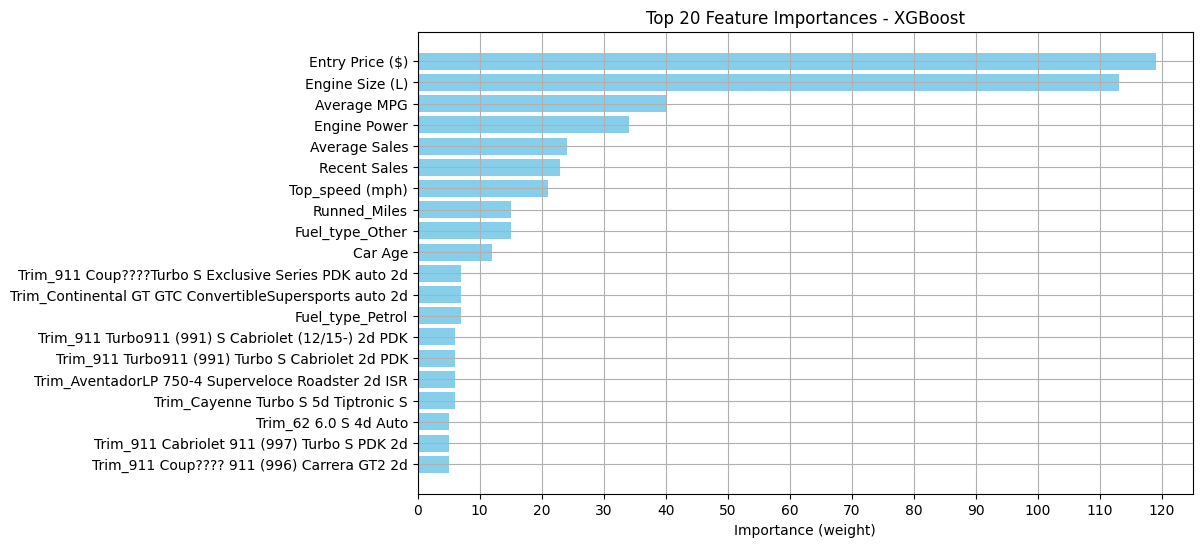

In [39]:
# Determining Feature Importance using XGBoost

xgb_pipeline.fit(X, y)
xgb_model = xgb_pipeline.named_steps['regressor']

num_features = numeric_features
cat_features = xgb_pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = np.concatenate([num_features, cat_features])

importance_dict = xgb_model.get_booster().get_score(importance_type='weight')
importance_items = [(all_feature_names[int(k[1:])], v) for k,v in importance_dict.items()]
importance_items = sorted(importance_items, key=lambda x: x[1], reverse=True)

importance_df = pd.DataFrame(importance_items, columns=['Feature', 'Importance']).head(20)

plt.figure(figsize=(10,6))
plt.barh(importance_df['Feature'][::-1], importance_df['Importance'][::-1], color='skyblue')
plt.xlabel('Importance (weight)')
plt.xticks(np.arange(0,130,10))
plt.title('Top 20 Feature Importances - XGBoost')
plt.grid()

plt.savefig("../screenshots/feature_importance_plot.png", dpi=300, bbox_inches='tight')

plt.show()


Interestingly, none of the categorical features such as body type, fuel type, or color appear in the top 5 important predictors. This suggests that car pricing is more strongly determined by quantitative performance and pricing metrics than by categorical attributes.

Entry Price and Engine Size are the key features in determining the price of a car, followed by Average MPG whose impact is roughly one-third that of Entry Price. The influence of other features on car prices gradually declines further. Therefore, the top 5 features are considered for model deployment.

In [40]:
top_features = ['Entry Price ($)', 'Engine Size (L)',  'Average MPG','Engine Power', 'Average Sales']
X = df[top_features]
y = df['Price ($)']

# Using Ridge Regression for model deployment
ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=1.0))
])

# Using Cross-validation to check performance 
cv = KFold(n_splits=5, shuffle=True, random_state=42)

r2_scores = cross_val_score(ridge_pipeline, X, y, cv=cv, scoring='r2')
mae_scores = -cross_val_score(ridge_pipeline, X, y, cv=cv, scoring='neg_mean_absolute_error')

print("Cross-validation with Top 5 features:")
print(f"R²: {r2_scores.mean():.3f} ± {r2_scores.std():.3f}")
print(f"MAE: {mae_scores.mean():.2f} ± {mae_scores.std():.2f}")

ridge_pipeline.fit(X, y)

# Saving the model 
joblib.dump(ridge_pipeline, "../models/ridge_model.pkl")
print("Ridge Regression retrained on Top 5 features and saved for Streamlit app!")



Cross-validation with Top 5 features:
R²: 0.938 ± 0.002
MAE: 2474.35 ± 11.92
Ridge Regression retrained on Top 5 features and saved for Streamlit app!


Reducing to the top 5 numeric features slightly increased MAE compared to the full-feature model, but the R² remains high.        This confirms that the model still captures the majority of the variance in car prices.